## 목표: '다중선형회귀 모델' 구현
### Dataset: ../data/robot_data.csv
알아두기: 단순 선형회귀와 달리 다중선형회귀는 특징을 여러 개 받아서 하나의 결과값을 예측함
*전체 흐름*
1. pandas로 CSV 불러오기
2. 데이터 확인
3. 입력 X, 정답 y 나누기
4. train/test 분리
5. Tensor로 변환
6. 모델 생성
7. loss, optimizer 설정
8. 학습
9. 예측
10. 평가

In [ ]:
# PyTorch 관련 라이브러리
import torch
import torch.nn as nn
import torch.optim as optim

# 데이터 처리 라이브러리
import numpy as np
import pandas as pd

# 그래프 시각화 라이브러리
import matplotlib.pyplot as plt

# 학습 데이터 / 테스트 데이터 분리
from sklearn.model_selection import train_test_split

# 모델 평가 지표
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'현재 사용 중인 디바이스: {device}')

현재 사용 중인 디바이스: mps


In [3]:
# 1. pandas로 CSV 불러오기
df = pd.read_csv('../data/robot_data.csv')

In [4]:
# 2. 데이터 확인
df.head()

,speed,distance,battery,energy
0,4.37,6.41,71.36,19.17
1,9.56,33.64,26.73,37.31
2,7.59,19.15,32.93,32.34
3,6.39,27.89,91.88,37.18
4,2.40,45.84,68.51,30.52


In [5]:
# 3. 입력 X, 정답 y 나누기

# X(속도+거리+배터리): 3가지 특성을 사용해 y('energy')를 예측
X = df[['speed', 'distance', 'battery']]
y = df[['energy']]

# 결과: (데이터수(행): 100개, 속성)
print(X.shape)
print(y.shape)

(100, 3)
(100, 1)


In [6]:
# 4. train/test 분리

# 평가 비율(8:2)
# 난수 시드는 자유입니다
# TMI. 42로 한 이유는 SF 소설 <은하수를 여행하는 히치하이커를 위한 안내서>에서 슈퍼 컴퓨터가 750만 년 동안 우주의 진리를 계산한 답이 42라고 하네요
# 그리고 증명은 안 됐지만 강사님이 다른 랜덤시드값보다 42로 했을 때 잘 나오는 것 같다는 아주 개인적인 소견도...내놓으셨습니다
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80, 3)
(20, 3)
(80, 1)
(20, 1)


In [7]:
# 5. Tensor로 변환
X_train = torch.tensor(X_train.to_numpy(), dtype=torch.float32)
X_test = torch.tensor(X_test.to_numpy(), dtype=torch.float32)
y_train = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

print(type(X_train))
print(type(X_test))
print(type(y_train))
print(type(y_test))

<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [8]:
# 6. 모델 생성

# 단순 선형회귀와 다르게 다중 선형회귀는 클래스로 선언해 진행하겠습니다
class Multi(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1)

    def forward(self, x):
        return self.linear(x)

In [15]:
# 7. loss, optimizer 설정

# 모델 학습할 때 weight, bias가 랜덤값으로 설정되는데 동일한 결과를 얻기 위해 고정
# 지금은 큰 의미가 없지만 추후에 모델을 보완할 때 값을 고정시켜야 다양한 방법론 사용할 때 비교가 용이합니다
torch.manual_seed(42)
# 위에서 정의한 클래스(모델) 호출
model = Multi()

# loss 설정
loss_fn = nn.MSELoss()

# optimizer 설정
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)

# 현재는 기본 단계라 심화적인 내용은 안 했지만 심화 과정을 공부할 땐
# Adam, Learning Scheduler 등과 같은 기법들도 추가하겠습니다

In [16]:
# 8. 학습

epochs = 1000
loss_history = []

for epoch in range(epochs):
    # 1. 예측값 계산
    pred = model(X_train)

    # 2. 예측값과 실제값의 차이 계산
    loss = loss_fn(pred, y_train)

    # 3. 이전 gradient 초기화
    optimizer.zero_grad()

    # 4. 역전파로 gradient 계산
    loss.backward()

    # 5. weight, bias 업데이트
    optimizer.step()

    # Loss 저장
    loss_history.append(loss.item())

    # 100번마다 loss 출력
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss_history[-1]:.4f}')

Epoch [100/1000], Loss: 19.9509
Epoch [200/1000], Loss: 14.3546
Epoch [300/1000], Loss: 10.5995
Epoch [400/1000], Loss: 8.0798
Epoch [500/1000], Loss: 6.3891
Epoch [600/1000], Loss: 5.2545
Epoch [700/1000], Loss: 4.4931
Epoch [800/1000], Loss: 3.9822
Epoch [900/1000], Loss: 3.6393
Epoch [1000/1000], Loss: 3.4090


In [25]:
# 9. 예측

# 모델 평가모드로 변경
model.eval()

with torch.no_grad():
    pred = model(X_test)
    test_loss = loss_fn(pred, y_test)
    # Epoch Loss = 학습 데이터(X_train, y_train)로 계산한 오차
    # Test Loss = 테스트 데이터(X_test, y_test)로 계산한 오차
    print(f'Test Loss: {test_loss.item():.4f}\n')

for i in range(5):
    print(f'실제 값: {y_test[i].item():.2f}, 예측 값: {pred[i].item():.2f}')

Test Loss: 8.0059

실제 값: 28.17, 예측 값: 29.33
실제 값: 32.25, 예측 값: 35.92
실제 값: 43.61, 예측 값: 42.42
실제 값: 25.48, 예측 값: 26.72
실제 값: 18.09, 예측 값: 18.13


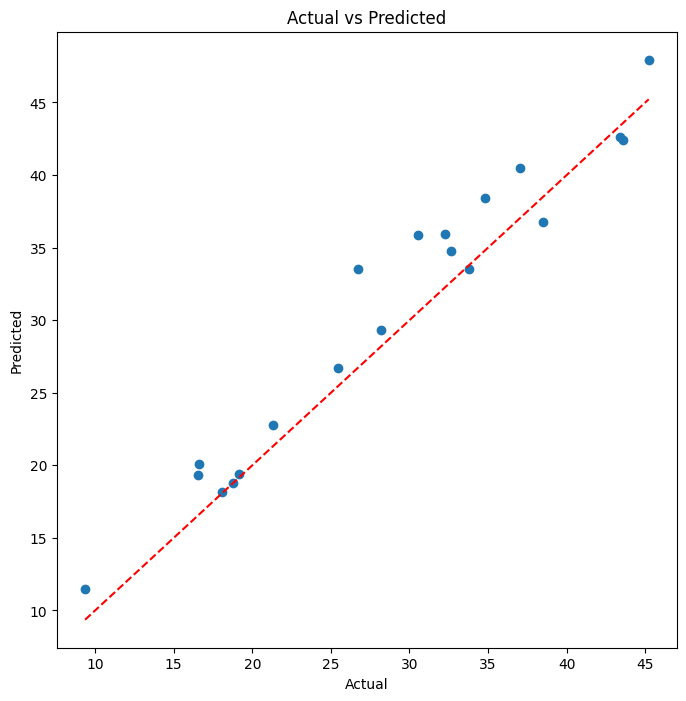

R² Score: 0.9203


In [36]:
# 10. 평가
from sklearn.metrics import r2_score

plt.figure(figsize=(8, 8))
plt.scatter(y_test.numpy(), pred.numpy())
plt.plot([y_test.min().item(), y_test.max().item()], [y_test.min().item(), y_test.max().item()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

# 모델이 데이터를 얼마나 잘 설명하는지를 나타내는 지표로 0.8 이상이면 우수합니다(단, 데이터의 특성에 따라 달라질 수 있습니다)
r2 = r2_score(
    y_test.numpy(),
    pred.numpy()
)

print(f'R² Score: {r2:.4f}')